# Take-home Challenge - Offer Acceptance

**Problem framing (business + ML)**
- Goal: Predict each customer’s probability of accepting an offer so we can rank customers and decide who should receive an offer
- Decision we enable: Given a limited budget (or a target number of offers), send offers to the top-K ranked customers to maximize expected acceptances

**Success criteria**
- Primary: Strong ranking quality so that the top of the list contains the most likely accepters
- Metrics: Precision @ K/ Lift @ K, and PR-AUC
- Business Alignment: More acceptance per dollar (maximize acceptances while controlling spend)

**Deliverables:**
- `EDA (10 minutes)`: Missingness, Duplicates, Basic Distributions, Target Prevalence, Conversion Rate by Category (2-3 plots max), Data Split (X, y)
- `Baseline Model (5 min)`: Prevalence (random targeting conversion rate) -> lift baseline = 1.0
- `Modeling (20 min)`: Logistic Regression Pipeline (Data Preprocessing + LR model for imbalance data) + Stratified CV 
- `Evaluation (10 min)`: PR-AUC, Lift @ K, Precision @ K
- `Feature Importance (10 min)`: Show Top positive/ negative coefficients, Interpret action features (discount, duration, channel) carefully

**Highlights:**
- fast evidence, clear decisions

**Precision/ Lift @ K**
- In reality, conversions are rare, and we typically have limited budget to send offers, the business decision is to target the top K customers. So Precision @ K and Lift @ K directly measure the value of the model at the operating point. I also report PR-AUC as a threshold-free measure of ranking quality under class imbalance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# 1. Data Overview

After loading the data, I will first check:
- data shape
- data duplicates
- data missingness
- target prevalence
- if any potential leakage columns (e.g. user id, timestamp)
- feature types & basic feature type split

In [ ]:
data = pd.read_csv("data/customer_offer_acceptance.csv")
data.head()

,segment,channel,region,offer_type,age,days_since_last_activity,prior_30d_sessions,prior_30d_purchases,prior_30d_open_rate,discount_pct,offer_valid_days,local_hour,accepted
0,active,push,EU,loyalty_points,25.217945,12.076669,13,3,0.406726,16.045282,7,10,0
1,vip,email,NaN,loyalty_points,52.752736,0.778956,6,0,0.302145,20.357171,10,23,0
2,churn_risk,email,NaN,percent_off,42.585978,0.241288,9,1,0.206585,6.714107,10,12,0
3,active,push,LATAM,percent_off,18.000000,35.555560,7,4,0.192540,15.776942,1,22,0
4,new,email,LATAM,free_shipping,24.366053,15.714874,3,0,0.396323,25.587322,5,14,0


- How User Use the Restaurant Service: age, region, days_since_last_activity, piror_30d_sessions, prior_30d_purchases, prior_30d_open_rates, local_hour -> customer past interactions with restaurants
- Action: offer_type, channel, discount_pct, segment -> offer feature 
- Conversion Outcome: accepted

In [3]:
target = "accepted"

In [4]:
data.shape

(12000, 13)

In [5]:
# check data duplicates -> no duplicates
data.duplicated().sum()

0

In [6]:
# check data missing -> preprocess data when building ML pipelines
data.isna().mean().sort_values(ascending=False)

region                      0.563083
prior_30d_open_rate         0.059500
discount_pct                0.041583
age                         0.031250
segment                     0.000000
channel                     0.000000
offer_type                  0.000000
days_since_last_activity    0.000000
prior_30d_sessions          0.000000
prior_30d_purchases         0.000000
offer_valid_days            0.000000
local_hour                  0.000000
accepted                    0.000000
dtype: float64

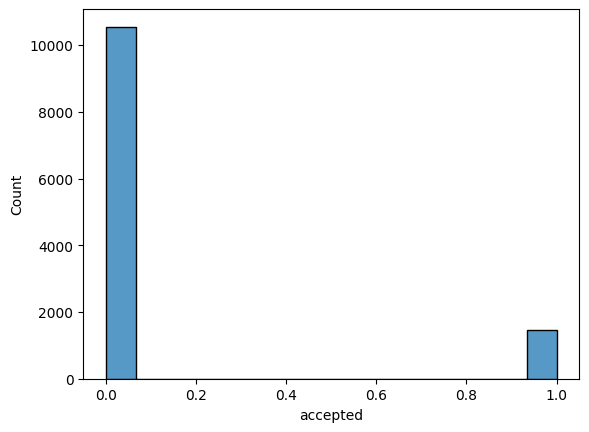

In [7]:
# check target prevalence -> highly imbalance binary classification problem
# need to take care when building ML pipelines 
# (e.g. split the data, loss function, evaluation metrics)

sns.histplot(data=data, x=data.accepted); 

In [8]:
# check data dtypes
data.dtypes

segment                      object
channel                      object
region                       object
offer_type                   object
age                         float64
days_since_last_activity    float64
prior_30d_sessions            int64
prior_30d_purchases           int64
prior_30d_open_rate         float64
discount_pct                float64
offer_valid_days              int64
local_hour                    int64
accepted                      int64
dtype: object

In [9]:
X = data.drop(columns=[target])
y = data[target]

num_cols = X.select_dtypes([np.number]).columns.tolist()
cat_cols = X.select_dtypes(["O"]).columns.tolist()

print("Numeric Cols: ", num_cols)
print("Categorical Cols: ", cat_cols)

Numeric Cols:  ['age', 'days_since_last_activity', 'prior_30d_sessions', 'prior_30d_purchases', 'prior_30d_open_rate', 'discount_pct', 'offer_valid_days', 'local_hour']
Categorical Cols:  ['segment', 'channel', 'region', 'offer_type']


In [10]:
### check conversion rate by category
for i, feature in enumerate(cat_cols):
    print(feature)
    print(data.groupby([feature])[target].mean())

segment
segment
active        0.134142
churn_risk    0.109595
new           0.101282
vip           0.131399
Name: accepted, dtype: float64
channel
channel
email     0.119103
in_app    0.108319
push      0.130777
sms       0.124424
Name: accepted, dtype: float64
region
region
APAC     0.118068
EU       0.123766
LATAM    0.116402
Name: accepted, dtype: float64
offer_type
offer_type
bogo              0.123034
free_shipping     0.120678
loyalty_points    0.112684
percent_off       0.122768
Name: accepted, dtype: float64


# 2. Modeling

`Stratified Data Split`

- I will keep a final holdout test set and only evaluate on it once at the end. 
- All model selection decisions (like number of offers we decide to send) will be done using only training folds to avoid optimistic bias.

In [11]:
# stratified data split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40, stratify=y)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)
print("Train Prevalence:", y_train.mean())
print("Test Prevalence:", y_test.mean())

Train Size: (9600, 12)
Test Size: (2400, 12)
Train Prevalence: 0.12072916666666667
Test Prevalence: 0.12083333333333333


`baseline model` (benchmark)
- A baseline model anchors expectations.
- If my model cannot beat a stratified baseline model on PR-AUC and Lift @ K, it would not be useful.
- This can also help us explain to our clients what a good model looks like.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold

RANDOM_STATE = 40

- The goal is Top-K ranking
- The baseline model needs to produce a score that actually orders users.

In [13]:
# The dumbest model would always predict the base rate
p = y_train.mean()

# for top-k evaluation, we need a ranking
# randomly assign a ranking score near p
baseline_prob = p + 1e-6 * np.random.RandomState(RANDOM_STATE).rand(len(y_test)) # uniform distributed in [0, 1)
baseline_prob

array([0.12072957, 0.12072922, 0.12072996, ..., 0.12073003, 0.12072974,
       0.12073002])

In [14]:
def evaluate_pred(y_true, y_prob, k_frac, model_name):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    
    # Pick top K customers to send the offer
    k = max(int(k_frac * len(y_prob)), 1)
    topk_idx = np.argsort(-y_prob)[:k]
    
    # Precision @ K, Lift @ K
    precision_k = y_true[topk_idx].mean()
    prevalence = y_true.mean()
    lift_k = precision_k / prevalence if prevalence > 0 else np.nan
    
    # PR-AUC
    avg_precision = average_precision_score(y_true, y_prob)
    
    res = {
        "model": model_name,
        "average precision": avg_precision,
        "precision @ K": precision_k,
        "lift @ K": lift_k
    }
    
    return res

In [15]:
k_frac_list = [0.005, 0.01, 0.05, 0.10, 0.20]
baseline_rows = [evaluate_pred(y_test, baseline_prob, k_frac=k, model_name=f"Random Baseline (Top {k*100}%)") for k in k_frac_list]
baseline_df = pd.DataFrame(baseline_rows)
baseline_df

,model,average precision,precision @ K,lift @ K
0,Random Baseline (Top 0.5%),0.128856,0.166667,1.379310
1,Random Baseline (Top 1.0%),0.128856,0.125000,1.034483
2,Random Baseline (Top 5.0%),0.128856,0.116667,0.965517
3,Random Baseline (Top 10.0%),0.128856,0.120833,1.000000
4,Random Baseline (Top 20.0%),0.128856,0.150000,1.241379


- Later, I will compare the Logistic Regression model with the baseline model here, checking if the scores can beat the benchmark.

# 3. Preprocessing Pipeline

- All data preprocessing would be put inside a pipeline to prevent from any data leakage.

- numeric features: median impute + standardize
- categorical features: most-frequent impute + one-hot encode
- OneHotEncoder: use handle_unknown="ignore" in case any categories that never appeared in the training set appear in the validation set or test set

In [16]:
### Preprocess numerical features and categorical features separately

def build_preprocessor(X_):
    num_cols = X_.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [i for i in X_.columns if i not in num_cols]
    
    num_pipeline = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")), 
        ("scaler", StandardScaler()), # make numeric features comparable and well-behaved for the optimizer
    ])

    cat_pipeline = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    # ColumnTransformer
    preprocessor = ColumnTransformer(transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ])

    return preprocessor

preprocessor = build_preprocessor(X_train)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'days_since_last_activity',
                                  'prior_30d_sessions', 'prior_30d_purchases',
                                  'prior_30d_open_rate', 'discount_pct',
                                  'offer_valid_days', 'local_hour']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['segment', 'channel', 'region',
                               

# 4. Model: Logistic Regression

- Fast, stable, interpretable
- Works well with one-hot features
- Handles imbalance with class_weight = "balanced"

I will evaluate with cross validation with PR-AUC + classification metrics.
- accuracy is misleading when negatives dominate
- PR-AUC reflects minority-class ranking quality

In [17]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced", # key for imbalance: up-weight the minority class in the loss, making the rare "positives" cost more during training 
    solver="liblinear" # good for binary and small dataset
)

lr_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", log_reg)
])

- Use cross validation to choose K

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

`Precision/ Lift @ K`:
- No longer need to tune the LR threshold. Actually, no fixed threshold is used anymore.
- Top-K becomes the decision policy that converts probabilities/ scores into actions.
- It aligns better with the business needs/ actions: we may have limited resources when sending offers, and we would like the number of offers to be stable across time.

In [19]:
from sklearn.model_selection import cross_val_predict

# OOF probs (leakage-safe ranking)
oof_prob = cross_val_predict(lr_pipeline, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
oof_prob

array([0.54782044, 0.36142846, 0.27432891, ..., 0.68764053, 0.55279537,
       0.54798147])

In [20]:
res = []
k_frac_list = [0.005, 0.01, 0.05, 0.10, 0.20]
for k_frac in k_frac_list:
    row = evaluate_pred(y_train, oof_prob, k_frac=k_frac, model_name=f"LR (Top {k_frac*100}%)")
    res.append(row)
lr_eva_df = pd.DataFrame(res)
lr_eva_df

,model,average precision,precision @ K,lift @ K
0,LR (Top 0.5%),0.195974,0.291667,2.415876
1,LR (Top 1.0%),0.195974,0.302083,2.502157
2,LR (Top 5.0%),0.195974,0.258333,2.139776
3,LR (Top 10.0%),0.195974,0.220833,1.829163
4,LR (Top 20.0%),0.195974,0.201563,1.669543


In [21]:
baseline_df

,model,average precision,precision @ K,lift @ K
0,Random Baseline (Top 0.5%),0.128856,0.166667,1.379310
1,Random Baseline (Top 1.0%),0.128856,0.125000,1.034483
2,Random Baseline (Top 5.0%),0.128856,0.116667,0.965517
3,Random Baseline (Top 10.0%),0.128856,0.120833,1.000000
4,Random Baseline (Top 20.0%),0.128856,0.150000,1.241379


In [22]:
print("Compared with the baseline model, the logistic regression model: ")
print("Lift @ K beats:", round(lr_eva_df.iloc[1, 3] / baseline_df.iloc[1, 2], 3), "X")
print("Precision @ K beats:", round(lr_eva_df.iloc[1, 2] / baseline_df.iloc[1, 2], 2), "X")
print("Average Precision beats:", round(lr_eva_df.iloc[1, 1] / baseline_df.iloc[1, 1], 2), "X")

Compared with the baseline model, the logistic regression model: 
Lift @ K beats: 20.017 X
Precision @ K beats: 2.42 X
Average Precision beats: 1.52 X


In [23]:
# will choose top 1% customers to send the offer based on cv results
CHOSEN_K_FRAC = 0.01

# 5. Fit final model on full training set, evaluate on test once

In [24]:
lr_pipeline.fit(X_train, y_train)
test_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
test_prob_lr

array([0.70998281, 0.65726533, 0.41639293, ..., 0.53121099, 0.43689413,
       0.37999842])

In [25]:
# Apply the same Top-K policy on test
evaluate_pred(y_test, test_prob_lr, k_frac=CHOSEN_K_FRAC, model_name="LR (Top 1%)")

{'model': 'LR (Top 1%)',
 'average precision': 0.21803544904599403,
 'precision @ K': 0.3333333333333333,
 'lift @ K': 2.758620689655172}

# 6. Model Evaluation

- `PR + ROC Curves` on validation predictions

In [26]:
from sklearn.metrics import precision_recall_curve, roc_curve

Text(0, 0.5, 'TPR')

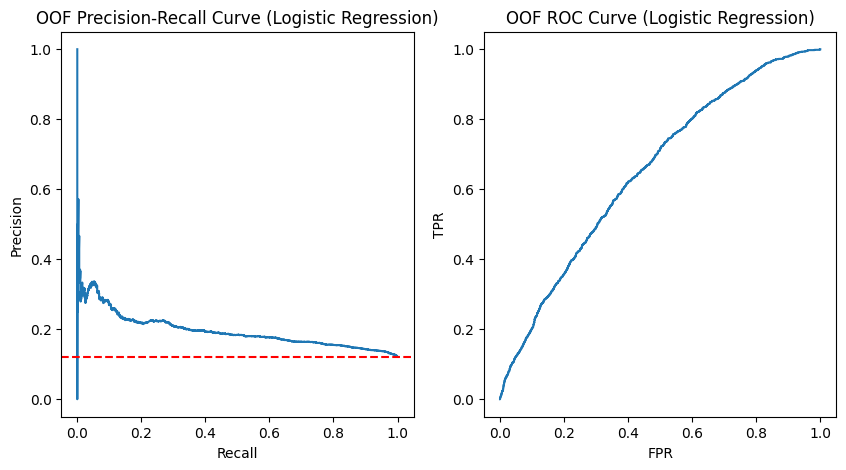

In [27]:
# PR + ROC curves on OOF predictions (train)
prec, rec, pr_thr = precision_recall_curve(y_train, oof_prob)
fpr, tpr, roc_thr = roc_curve(y_train, oof_prob)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax = ax.flatten()

ax[0].plot(rec, prec)
ax[0].axhline(y_train.mean(), color="red", linestyle="--")
ax[0].set_title("OOF Precision-Recall Curve (Logistic Regression)")
ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")

ax[1].plot(fpr, tpr)
ax[1].set_title("OOF ROC Curve (Logistic Regression)")
ax[1].set_xlabel("FPR")
ax[1].set_ylabel("TPR")

These are the PR/ROC curves computed on out-of-fold probabilities from cross_val_predict. For imbalanced data, PR is the key curve: the dashed line is prevalence, so being above it means we beat random ranking. Precision Drops as recall rises, which is expected: to capture more positives we accept more false positives. ROC looks decent, but it can be over optimistic in imbalanced settings, so I rely more on average precision and top K precision/ lift to match the business workflow.

# 6. Feature Importance

- Logistic Regression Coefficients (Directional Drivers)

In [28]:
import numpy as np
import pandas as pd

pre = lr_pipeline.named_steps["preprocess"]
model = lr_pipeline.named_steps["model"]

num_names = num_cols

# 3) categorical names from the OneHotEncoder only
ohe = pre.named_transformers_["cat"].named_steps["encoder"]  # change "encoder" if needed
cat_names = ohe.get_feature_names_out(cat_cols).tolist()

feature_names = num_names + cat_names

# 4) coefficients
coef = model.coef_.ravel()
s = pd.Series(coef, index=feature_names).sort_values()
s

days_since_last_activity    -0.561829
segment_new                 -0.218717
channel_in_app              -0.184297
segment_churn_risk          -0.116672
offer_type_loyalty_points   -0.085230
region_APAC                 -0.073895
channel_email               -0.023666
offer_type_percent_off      -0.021327
region_LATAM                -0.013384
region_EU                   -0.009013
offer_type_free_shipping    -0.004361
age                          0.011086
offer_valid_days             0.013823
offer_type_bogo              0.014626
channel_sms                  0.025647
prior_30d_sessions           0.060082
channel_push                 0.086024
local_hour                   0.086716
segment_vip                  0.101468
segment_active               0.137629
prior_30d_open_rate          0.194333
discount_pct                 0.203200
prior_30d_purchases          0.229302
dtype: float64

`Feature importance (Logistic Regression)`:

- I interpret importance using the logistic regression coefficients in log-odds space. 
- Since numerical features are StandardScaled, each numeric coefficient represents the effect of a +1 standard deviation change. 
- For categorical features, we use one-hot encoding, so each coefficient represents the effect of belonging to that category level (0→1) relative to the reference level.
- To compare impact across feature types, I convert coefficients to odds ratios using exp(𝛽): numeric odds ratios are per +1 SD, while categorical odds ratios are for category membership. Raw coefficient magnitudes aren’t perfectly apples-to-apples because the “unit change” differs, but odds ratios make the effects directly interpretable.
- In our results, the strongest negative drivers meaningfully reduce odds (e.g., higher inactivity), while the strongest positive drivers increase odds (e.g., higher recent engagement/purchases), which aligns with intuition and serves as a sanity check on the model.

# 5. Summary & Next Steps


- **Imbalance:** acceptance is rare, so I evaluated with **PR-AUC** and tuned threshold for a precision/recall tradeoff.  
- **Modeling:** I used a leakage-safe **Pipeline** (impute/scale/one-hot) with **LogReg baseline**
- **Drivers:** engagement + recency + offer attributes + segment/channel differences.  
- **Next steps:** probability calibration, segment-aware thresholds, and uplift modeling to target *persuadable* users.
